# Black-hole vs HMNS engines for kilonova-producing GRBs

## Methods

Eight kilonova-bearing short and long-merger GRBs from Rastinejad et al.
(2024, ApJ 979, 190; Tables 1 and 3) are tested against two engine
models. **(i) Black-hole engine.** Gottlieb et al. (2025, arXiv:2411.13657)
Eq. (11) gives $M_{\rm ej}=10^{-3}\,f_{-1}^{-1}\,(E_{\gamma,\rm iso}/2{\times}10^{51}\,{\rm erg})\,(T_{50}/{\rm s})^{\alpha-1}\,M_\odot$.
The shown band marginalises $\alpha\in[1.5,2]$ and $f^{-1}\in[0.14,5]$,
the latter implied by their Eq. (10) with $\epsilon_\gamma\in[0.15,0.5]$
and $f_b\in[0.01,0.11]$. **(ii) HMNS / magnetar disk-wind alternative.**
$M_{\rm ej}=0.3\,M_d$ (Gottlieb et al. 2025 §3.1; consistent with
$f_{\rm wind}\sim0.2{-}0.4$ in Radice et al. 2018, arXiv:1809.11163),
with $M_d\in[0.01,0.10]\,M_\odot$ from the BNS post-merger disk fit of
Krüger & Foucart (2020, arXiv:2002.07728, Eq. 4). Per-event $T_{50}$
overrides for GRBs 050709 (Villasenor et al. 2005, Nature 437, 855),
170817A (Goldstein et al. 2017, ApJL 848, L14, Tab. 1), and 230307A
($T_{90}/2$ from Levan et al. 2024) are documented in the
[`Data/rastinejad_2024.csv`](Data/rastinejad_2024.csv) header. Posterior
inference uses $10^4$ Monte Carlo draws over the Rastinejad split-normal
ejecta-mass posteriors and the $E_{\gamma,\rm iso}$, $\alpha$, $f$
priors; per-subclass mean log-ratios and a Gaussian-in-log Bayes factor
$B_{10}=P({\rm data}\mid{\rm HMNS})/P({\rm data}\mid{\rm BH})$ are
printed below Fig. 2.

## Figures

**Figure 1.** $M_{\rm ej}$ vs $T_{50}$. Grey BH-engine band evaluated at
the *in-sample* lbGRB geometric mean of $E_{\gamma,\rm iso}$ (the value
is printed in the lower-right footnote of the figure; this replaces a
prior 1.7e52-erg hard-code that did not match the 3-event geomean by
$\sim\!0.09$ dex). Inner shading marginalises $\alpha\!\in\![1.5,2]$
only; the outer dashed envelope adds $f^{-1}\!\in\![0.14,5]$. Green
HMNS-wind box bounded by $M_{\rm ej}\!=\!0.3\,M_d$ on the $x$-axis
(Krüger & Foucart 2020 / Gottlieb+25 §3.1) **and** $t_{\rm HMNS}\!\in\!
[0.1,10]\,{\rm s}$ on the $y$-axis (magnetar spin-down / viscous time;
Lippuner+17, Fujibayashi+18, Metzger 2019). Per-event 3-wedge donuts
show the lanthanide-rich / intermediate / lanthanide-poor median mass
fractions ($M_R$, $M_P$, $M_B$) from Rastinejad (2024) Table 3, drawn
off-marker with thin grey leaders so the data dot is not painted
through. Error bars are 68% posterior intervals on $M_{\rm tot}$ and
published $T_{50}$. The asterisk on 230307A flags the $T_{50}\!=\!
T_{90}/2$ Levan+24 estimate.

**Figure 2.** $\log_{10}(M_{\rm obs}/M_{\rm pred,BH})$ per event with
68% MC bars on the joint $(M_{\rm obs},E_{\gamma,\rm iso},\alpha,f,T_{50})$
posterior. Teal `+` symbols (with 68% MC bars on a log-uniform $M_d$
prior) show the HMNS-wind prediction. Grey band: Gottlieb+25's
factor-of-3 agreement criterion. GW170817 is drawn as an open marker
without a $y$-error bar because its prompt $E_{\gamma,\rm iso}$ is
off-axis cocoon emission (Goldstein+17, Mooley+18), so Eq. (11) is
misapplied rather than just discrepant.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from grb_physics import (
    GOTTLIEB25_F_RANGE,
    GOTTLIEB25_DISK_RANGE,
    GOTTLIEB25_WIND_FRAC,
    GOTTLIEB25_T_HMNS_RANGE,
    gottlieb25_eq11,
    hmns_wind_ejecta,
)

PLOTS_DIR = "Plots"
DATA_DIR  = "Data"
CSV_PATH  = os.path.join(DATA_DIR, "rastinejad_2024.csv")
os.makedirs(PLOTS_DIR, exist_ok=True)

# ApJ single-column rcParams. Caller scripts can override.
mpl.rcParams.update({
    "figure.figsize":     (3.5, 3.0),
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.format":     "pdf",
    "font.size":          8,
    "font.family":        "serif",
    "mathtext.fontset":   "cm",
    "axes.linewidth":     0.7,
    "axes.labelsize":     9,
    "axes.titlesize":     9,
    "xtick.labelsize":    7,
    "ytick.labelsize":    7,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          True,
    "ytick.right":        True,
    "legend.fontsize":    7,
    "legend.frameon":     True,
    "legend.framealpha":  0.92,
    "lines.linewidth":    1.0,
})

# Read the canonical Rastinejad+24 table.  See CSV header for column
# definitions, the component-to-origin mapping (M_B dynamical vs
# M_P + M_R disk wind), and T_50 source notes.
df = pd.read_csv(CSV_PATH, comment="#", skipinitialspace=True)
df["E_iso_erg"]     = df["E_iso_52"]     * 1e52
df["E_iso_err_erg"] = df["E_iso_err52"]  * 1e52

# Per-event T_50 prior overrides.  Default is a clipped Gaussian with
# (T50_s, T50_err_s) from the CSV; events listed here use a log-space
# prior that honours the "upper bound only" (050709) and
# "T_90/2 with factor-2 width" (230307A) caveats documented in the CSV
# header.
#
#   ("logunif", lo, hi)   -- log-uniform on [lo, hi] (Jeffreys-type prior)
#   ("lognormal", mu, s)  -- ln T_50 ~ N(ln(mu), s)
T50_PRIOR_OVERRIDES = {
    "050709":  ("logunif",   0.02, 0.07),
    "230307A": ("lognormal", 17.5, np.log(2.0)),
}


def sample_T50(row, n, rng):
    """Draw ``n`` T_50 samples for one event honouring any prior override."""
    prior = T50_PRIOR_OVERRIDES.get(row["name"])
    if prior is None:
        return np.clip(
            rng.normal(row.T50_s, max(row.T50_err_s, 1e-3 * row.T50_s), n),
            1e-6 * row.T50_s, None,
        )
    kind = prior[0]
    if kind == "logunif":
        return 10.0 ** rng.uniform(np.log10(prior[1]), np.log10(prior[2]), n)
    if kind == "lognormal":
        return rng.lognormal(mean=np.log(prior[1]), sigma=prior[2], size=n)
    raise ValueError(f"Unknown T_50 prior kind: {kind!r}")


# ---------------------------------------------------------------------------
# Posterior sampling: split-normal sampler -> 1e4 draws of M_B, M_P, M_R,
# M_tot, and M_wind per event.  M_wind = M_P + M_R is the disk-wind mass
# used by the Fig. 2 residual (Metzger 2019 mapping; see CSV header).
# ---------------------------------------------------------------------------
def sample_split_normal(med, lo, hi, n, rng, clip_zero=True):
    """Draw n samples from a split-normal centered at `med` with half-widths
    `lo` (below) and `hi` (above), interpreted as 1-sigma.  Tiny widths
    fall back to a 5%-of-median floor so that posteriors with reported
    +/-0 stay finite.
    """
    floor = max(1e-6, 0.05 * abs(med))
    sigma_lo = max(abs(lo), floor)
    sigma_hi = max(abs(hi), floor)
    u = rng.uniform(size=n)
    above = u < sigma_hi / (sigma_lo + sigma_hi)
    z = np.abs(rng.standard_normal(n))
    out = np.where(above, med + sigma_hi * z, med - sigma_lo * z)
    if clip_zero:
        out = np.clip(out, 0.0, None)
    return out


def build_posteriors(df, n=10_000, seed=0):
    """For every GRB return n samples of M_B, M_P, M_R, M_tot, M_wind."""
    rng = np.random.default_rng(seed)
    out = {}
    for _, row in df.iterrows():
        m_b = sample_split_normal(row.M_B_med, row.M_B_lo, row.M_B_hi, n, rng)
        m_p = sample_split_normal(row.M_P_med, row.M_P_lo, row.M_P_hi, n, rng)
        m_r = sample_split_normal(row.M_R_med, row.M_R_lo, row.M_R_hi, n, rng)
        out[row["name"]] = {
            "M_B":    m_b,
            "M_P":    m_p,
            "M_R":    m_r,
            "M_tot":  m_b + m_p + m_r,
            "M_wind": m_p + m_r,
        }
    return out


posteriors = build_posteriors(df, n=10_000, seed=20260417)

# Convenience: median + 16/84 percentiles of M_tot and M_wind for plotting.
def _summ(name, key):
    arr = posteriors[name][key]
    med = np.median(arr)
    lo  = med - np.percentile(arr, 16)
    hi  = np.percentile(arr, 84) - med
    return med, lo, hi


for key in ("M_tot", "M_wind"):
    df[f"{key}_med"] = [_summ(n, key)[0] for n in df["name"]]
    df[f"{key}_lo"]  = [_summ(n, key)[1] for n in df["name"]]
    df[f"{key}_hi"]  = [_summ(n, key)[2] for n in df["name"]]

df[["name", "grb_class", "T50_s", "E_iso_52",
    "M_tot_med", "M_tot_lo", "M_tot_hi",
    "M_wind_med", "M_wind_lo", "M_wind_hi"]]


,name,grb_class,T50_s,E_iso_52,M_tot_med,M_tot_lo,M_tot_hi,M_wind_med,M_wind_lo,M_wind_hi
0,050709,sb,0.07,0.0310,0.090168,0.038836,0.056068,0.085306,0.038407,0.056097
1,060614,lb,43.20,0.5100,0.167003,0.096540,0.095258,0.150416,0.096855,0.094545
2,130603B,sb,0.06,0.2900,0.233313,0.096889,0.129379,0.216479,0.096152,0.128404
3,160821B,sb,0.28,0.0050,0.032686,0.013362,0.018061,0.029719,0.013425,0.018114
4,170817A,gw,0.60,0.0006,0.075269,0.002892,0.003019,0.071240,0.002849,0.002974
5,200522A,sb,0.38,0.0810,0.198898,0.079011,0.102931,0.152730,0.078657,0.103133
6,211211A,lb,21.20,1.7200,0.144011,0.054137,0.051262,0.137579,0.054311,0.051160
7,230307A,lb,17.50,2.9000,0.089576,0.020966,0.019925,0.077551,0.021069,0.019944


In [2]:
# Helpers built on the Gottlieb+25 Eq. (11) primitives in grb_physics.
# ---------------------------------------------------------------------------
# The BH-engine band spans the (alpha, f) prior advertised on Fig. 1.  The
# HMNS-wind band evaluates 0.3 * M_d on the Kruger & Foucart 2020 disk-mass
# range.  Alpha prior is [1.5, 2.0] by default (Gottlieb+25 Fig. 4), but
# overridable so that the Fig. 3 alpha-sensitivity panel can use
# alpha = 1 (no T_50 dependence) to check whether the sb/lb separation is
# driven by the T_50^{alpha-1} scaling.


def bh_engine_band(T50_grid, E_iso, alpha_range=(1.5, 2.0),
                   f_range=GOTTLIEB25_F_RANGE, f_ref=0.1):
    """Return (alpha-only, alpha+f) prediction envelopes on a T50 grid."""
    T50_grid = np.asarray(T50_grid, dtype=float)
    a_lo, a_hi = alpha_range
    f_lo, f_hi = f_range
    finv_lo = f_ref / f_hi
    finv_hi = f_ref / f_lo

    inner_lo = gottlieb25_eq11(T50_grid, E_iso, alpha=a_lo, f_inv=1.0)
    inner_hi = gottlieb25_eq11(T50_grid, E_iso, alpha=a_hi, f_inv=1.0)
    inner = np.minimum(inner_lo, inner_hi), np.maximum(inner_lo, inner_hi)

    corners = []
    for a in (a_lo, a_hi):
        for fi in (finv_lo, finv_hi):
            corners.append(gottlieb25_eq11(T50_grid, E_iso, alpha=a, f_inv=fi))
    corners = np.stack(corners, axis=0)
    outer = corners.min(axis=0), corners.max(axis=0)
    return inner, outer


def hmns_wind_band(M_disk_range=GOTTLIEB25_DISK_RANGE,
                   wind_frac=GOTTLIEB25_WIND_FRAC):
    """Return (M_ej_lo, M_ej_hi) for the HMNS / magnetar disk-wind model."""
    return wind_frac * M_disk_range[0], wind_frac * M_disk_range[1]


def predict_bh_mc(row, n=10_000, rng=None,
                  alpha_range=(1.5, 2.0),
                  f_range=GOTTLIEB25_F_RANGE, f_ref=0.1):
    """Monte-Carlo predicted M_ej for one event under the BH-engine model.

    Marginalises over: alpha (uniform), f (log-uniform), E_iso (Gaussian),
    T50 (honouring any override in ``T50_PRIOR_OVERRIDES``).
    """
    if rng is None:
        rng = np.random.default_rng()
    alpha = rng.uniform(*alpha_range, size=n)
    log_f = rng.uniform(np.log10(f_range[0]), np.log10(f_range[1]), size=n)
    f_inv = f_ref / 10**log_f
    e_iso = np.clip(
        rng.normal(row.E_iso_erg, max(row.E_iso_err_erg, 1e-3 * row.E_iso_erg), n),
        1e-6 * row.E_iso_erg, None,
    )
    t50 = sample_T50(row, n, rng)
    return gottlieb25_eq11(t50, e_iso, alpha=alpha, f_inv=f_inv)


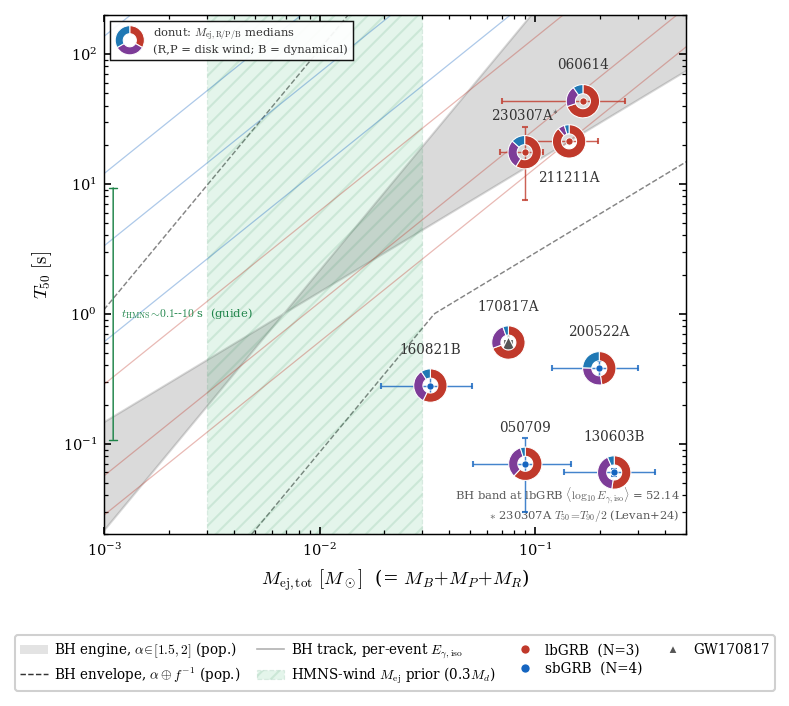

In [3]:
from matplotlib.patches import Wedge, Rectangle
from matplotlib.offsetbox import (AnnotationBbox, DrawingArea,
                                   AnchoredOffsetbox, HPacker, TextArea)

CLASS_STYLE = {
    # Colour-blind-safe palette.  The HMNS teal was moved to orange
    # (#d35400) in Fig. 2 to improve separation from the sbGRB blue under
    # protanopia simulation; the per-class dots below stay blue/red/grey.
    "lb": {"color": "#c0392b", "marker": "o", "label": r"lbGRBs"},
    "sb": {"color": "#1565c0", "marker": "o", "label": r"sbGRBs"},
    "gw": {"color": "#555555", "marker": "^", "label": r"GW170817"},
}
COMPONENT_COLORS = {
    "R": "#c0392b",  # red / lanthanide-rich (disk-wind MHD)
    "P": "#7d3c98",  # purple / intermediate (disk-wind thermal)
    "B": "#1f78b4",  # blue / lanthanide-poor (DYNAMICAL; not disk-wind)
}


def _make_donut_drawingarea(fractions, components=("R", "P", "B"),
                             radius_pts=8, inner_frac=0.45,
                             edge_color="white"):
    """Build a 3-wedge DrawingArea once; reusable for inline + legend swatch."""
    da = DrawingArea(2 * radius_pts, 2 * radius_pts, 0, 0)
    total = float(sum(fractions))
    if total <= 0:
        return None
    theta0 = 90.0
    for comp, frac in zip(components, fractions):
        theta1 = theta0 - 360.0 * (frac / total)
        da.add_artist(Wedge(
            (radius_pts, radius_pts), radius_pts, theta1, theta0,
            width=radius_pts * (1.0 - inner_frac),
            facecolor=COMPONENT_COLORS[comp], edgecolor=edge_color,
            linewidth=0.5,
        ))
        theta0 = theta1
    return da


def _add_donut(ax, x, y, fractions, components=("R", "P", "B"),
               radius_pts=8, inner_frac=0.45, edge_color="white",
               offset_pts=(0, 0), leader_color="0.55",
               leader_lw=0.5, zorder=6):
    """Place a 3-wedge donut at data coords (x, y), optionally offset."""
    da = _make_donut_drawingarea(fractions, components=components,
                                  radius_pts=radius_pts,
                                  inner_frac=inner_frac,
                                  edge_color=edge_color)
    if da is None:
        return None
    if offset_pts == (0, 0):
        ab = AnnotationBbox(da, (x, y), frameon=False,
                            xycoords="data", box_alignment=(0.5, 0.5),
                            pad=0)
    else:
        ab = AnnotationBbox(
            da, (x, y),
            xybox=offset_pts, boxcoords="offset points",
            xycoords="data", frameon=False,
            box_alignment=(0.5, 0.5), pad=0,
            arrowprops=dict(arrowstyle="-", lw=leader_lw,
                            color=leader_color,
                            shrinkA=0.0, shrinkB=0.0,
                            relpos=(0.5, 0.5)),
        )
    ab.set_zorder(zorder)
    ax.add_artist(ab)
    return ab


# Per-event donut and label offsets.  Donut offsets are zero so each
# donut sits centered on its data marker; label offsets place each event
# name 14 pt directly above its donut, except 211211A which is dropped
# below to keep its label clear of the 060614 / 230307A* labels in the
# upper-mid lbGRB cluster.
EVENT_OFFSETS_F1 = {
    "050709":  (0, 0, 0,  14, "center"),
    "060614":  (0, 0, 0,  14, "center"),
    "130603B": (0, 0, 0,  14, "center"),
    "160821B": (0, 0, 0,  14, "center"),
    "170817A": (0, 0, 0,  14, "center"),
    "200522A": (0, 0, 0,  14, "center"),
    "211211A": (0, 0, 0, -14, "center"),
    "230307A": (0, 0, 0,  14, "center"),
}
DEFAULT_OFFSET = (0, 0, 0, 14, "center")
LABEL_TEXT = {"230307A": r"230307A$^{\ast}$"}


def plot_fig1(df, posteriors, savepath_pdf,
              E_iso_ref=None, alpha_range=(1.5, 2.0),
              f_range=GOTTLIEB25_F_RANGE):
    """Duration-ejecta plane with population BH band, per-event BH tracks,
    HMNS-wind M_ej strip, and component-composition donuts.

    ``E_iso_ref=None`` (default) computes the geometric mean of the lbGRB
    ``E_iso`` values in this sample for the population band.  Per-event
    BH tracks (thin, class-coloured) are drawn at each event's own E_iso
    so the reader can match data points to their own prediction curves
    rather than only to the population average.
    """
    missing = set(df["name"]) - set(EVENT_OFFSETS_F1)
    assert not missing, (
        f"EVENT_OFFSETS_F1 missing entries for: {sorted(missing)}"
    )

    fig, ax = plt.subplots(figsize=(5.0, 4.5))

    if E_iso_ref is None:
        lb = df[df.grb_class == "lb"]
        E_iso_ref = float(10.0 ** np.log10(lb["E_iso_erg"]).mean())
        E_iso_ref_source = "in-sample lbGRB geomean"
    else:
        E_iso_ref_source = "user-specified"

    # Population BH band -- uses the in-sample lbGRB E_iso as its anchor.
    # Solves eq11 for T_50 given M_ej on a grid so the band runs along
    # the T_50 axis at a given (E_iso, alpha, f_inv) corner.
    M_grid = np.logspace(-3.5, 0.0, 400)
    norm = 1e-3 * E_iso_ref / 2e51
    # alpha-only envelope (f_inv = 1): T50 = (M/norm)^{1/(alpha-1)}
    inv_a2 = M_grid / norm
    inv_a15 = (M_grid / norm) ** 2.0
    band_alpha_lo = np.minimum(inv_a2, inv_a15)
    band_alpha_hi = np.maximum(inv_a2, inv_a15)
    ax.fill_between(M_grid, band_alpha_lo, band_alpha_hi,
                    color="0.2", alpha=0.18, zorder=1,
                    label=r"BH engine population, $\alpha\!\in\![1.5,2]$ 68% prior")

    finv_lo, finv_hi = 0.1 / f_range[1], 0.1 / f_range[0]
    corners_lo = []
    for a in alpha_range:
        for fi in (finv_lo, finv_hi):
            inv_full = (M_grid / (1e-3 * fi * E_iso_ref / 2e51)) ** (1.0 / (a - 1.0))
            corners_lo.append(inv_full)
    corners = np.stack(corners_lo, axis=0)
    env_lo, env_hi = corners.min(axis=0), corners.max(axis=0)
    ax.plot(M_grid, env_lo, ls="--", lw=0.7, color="0.2", alpha=0.6,
            zorder=1)
    ax.plot(M_grid, env_hi, ls="--", lw=0.7, color="0.2", alpha=0.6,
            zorder=1,
            label=r"BH engine population, $\alpha\oplus f^{-1}\!\in\![0.14,5]$ 68%")

    # Per-event BH tracks at alpha = 1.75 (prior midpoint).  Thin, faded,
    # in each event's class colour so the reader can line up each dot
    # with its own prediction curve.  GW170817 is skipped because its
    # off-axis E_iso makes Eq. (11) a misapplication at that data point
    # (see Fig. 2 for the on-axis-equivalent treatment).
    alpha_track = 0.5 * sum(alpha_range)
    for _, row in df.iterrows():
        if row.grb_class == "gw":
            continue
        c = CLASS_STYLE[row.grb_class]["color"]
        norm_i = 1e-3 * row.E_iso_erg / 2e51
        t50_of_m = (M_grid / norm_i) ** (1.0 / (alpha_track - 1.0))
        ax.plot(M_grid, t50_of_m, lw=0.6, color=c, alpha=0.35, zorder=2)

    # HMNS-wind M_ej prior: vertical strip (not box).  The T_50 extent of
    # the old box was an editorial overlay; neither Gottlieb+25 §3.1 nor
    # Lippuner+17 / Fujibayashi+18 / Metzger+19 claim the HMNS engine
    # predicts T_50.  A narrow bracket at the left edge marks the
    # HMNS spin-down / viscous timescale as a *guide* only.
    hmns_lo, hmns_hi = hmns_wind_band()
    ax.axvspan(hmns_lo, hmns_hi, facecolor="#27ae60", alpha=0.12,
               edgecolor="#1e8449", linewidth=0.6, linestyle="--",
               hatch="///", zorder=1)
    t_lo, t_hi = GOTTLIEB25_T_HMNS_RANGE
    # t_HMNS bracket: small vertical line at the very left of the axes.
    ax.annotate("", xy=(1.1e-3, t_lo), xytext=(1.1e-3, t_hi),
                arrowprops=dict(arrowstyle="|-|,widthA=0.25,widthB=0.25",
                                lw=0.7, color="#1e8449"),
                zorder=3)
    ax.text(1.2e-3, np.sqrt(t_lo * t_hi),
            r"$t_{\rm HMNS}\!\sim\!0.1$--$10$ s  (guide)",
            fontsize=5.5, color="#1e8449", ha="left", va="center",
            zorder=3)

    for _, row in df.iterrows():
        cls = "gw" if row.grb_class == "gw" else row.grb_class
        style = CLASS_STYLE[cls]
        x = row.M_tot_med
        y = row.T50_s
        x_err = np.array([[row.M_tot_lo], [row.M_tot_hi]])
        y_err = np.array([[row.T50_err_s], [row.T50_err_s]])
        ax.errorbar(x, y, xerr=x_err, yerr=y_err,
                    fmt="none", ecolor=style["color"], elinewidth=0.7,
                    capsize=1.5, alpha=0.8, zorder=4)
        post = posteriors[row["name"]]
        fracs = [np.median(post["M_R"]),
                 np.median(post["M_P"]),
                 np.median(post["M_B"])]
        donut_dx, donut_dy, lab_dx, lab_dy, lab_ha = EVENT_OFFSETS_F1.get(
            row["name"], DEFAULT_OFFSET)
        _add_donut(ax, x, y, fracs, radius_pts=8,
                   offset_pts=(donut_dx, donut_dy), zorder=6)
        if cls == "gw":
            ax.scatter(x, y, s=42, marker=style["marker"],
                       facecolor=style["color"], edgecolor="white",
                       linewidth=0.6, zorder=5)
        else:
            ax.scatter(x, y, s=12, marker=style["marker"],
                       facecolor=style["color"], edgecolor="white",
                       linewidth=0.4, zorder=5)
        v_align = "bottom" if lab_dy >= 0 else "top"
        ax.annotate(LABEL_TEXT.get(row["name"], row["name"]),
                    xy=(x, y),
                    xytext=(lab_dx, lab_dy), textcoords="offset points",
                    ha=lab_ha, va=v_align,
                    fontsize=6.5, color="0.2", zorder=7)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-3, 0.5)
    ax.set_ylim(0.02, 200)
    ax.set_xlabel(r"$M_{\rm ej,tot}\ [M_\odot]$  (= $M_B\!+\!M_P\!+\!M_R$)")
    ax.set_ylabel(r"$T_{50}\ [{\rm s}]$")

    n_lb = int((df.grb_class == "lb").sum())
    n_sb = int((df.grb_class == "sb").sum())
    handles = [
        mpl.patches.Patch(facecolor="0.4", alpha=0.18,
                          label=r"BH engine, $\alpha\!\in\![1.5,2]$ (pop.)"),
        plt.Line2D([0], [0], color="0.2", lw=0.7, ls="--",
                   label=r"BH envelope, $\alpha\oplus f^{-1}$ (pop.)"),
        plt.Line2D([0], [0], color="0.4", lw=0.8, alpha=0.5,
                   label=r"BH track, per-event $E_{\gamma,\rm iso}$"),
        mpl.patches.Patch(facecolor="#27ae60", alpha=0.12,
                          edgecolor="#1e8449", linewidth=0.6,
                          linestyle="--", hatch="///",
                          label=r"HMNS-wind $M_{\rm ej}$ prior (0.3$M_d$)"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["lb"]["color"], markersize=5,
                   label=f"lbGRB  (N={n_lb})"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["sb"]["color"], markersize=5,
                   label=f"sbGRB  (N={n_sb})"),
        plt.Line2D([0], [0], marker="^", color="w",
                   markerfacecolor=CLASS_STYLE["gw"]["color"], markersize=5,
                   label="GW170817"),
    ]
    ax.legend(handles=handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.18),
              fontsize=6.5,
              borderpad=0.4, handletextpad=0.5, labelspacing=0.35,
              ncol=4, columnspacing=1.2,
              frameon=True, framealpha=0.92)

    swatch_da = _make_donut_drawingarea([1.0, 1.0, 1.0], radius_pts=7)
    swatch_text = TextArea(r"donut: $M_{\rm ej, R/P/B}$ medians"
                           "\n"
                           r"(R,P = disk wind; B = dynamical)",
                           textprops=dict(fontsize=5.5, color="0.2"))
    swatch_box = HPacker(children=[swatch_da, swatch_text],
                         align="center", pad=0, sep=4)
    anchored_swatch = AnchoredOffsetbox(
        loc="upper left", child=swatch_box, frameon=True,
        pad=0.35, borderpad=0.4,
        bbox_to_anchor=(0.0, 1.0), bbox_transform=ax.transAxes,
    )
    anchored_swatch.patch.set_alpha(0.92)
    anchored_swatch.patch.set_linewidth(0.7)
    ax.add_artist(anchored_swatch)

    ax.text(
        0.99, 0.02,
        (r"BH band at lbGRB $\langle\log_{10}E_{\gamma,\rm iso}\rangle$"
         f" = {np.log10(E_iso_ref):.2f}\n"
         r"$\ast$ 230307A $T_{50}\!=\!T_{90}/2$ (Levan+24)"),
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=5.5, color="0.35",
    )

    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig


fig1 = plot_fig1(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig1.pdf"),
)
plt.show()


### Figure 1

| Element | Source |
| --- | --- |
| BH grey band ($\alpha\!\in\![1.5,2]$) | Eq. (11) of Gottlieb et al. 2025 ([arXiv:2411.13657](https://arxiv.org/abs/2411.13657)) |
| BH dashed envelope ($f^{-1}\!\in\![0.14,5]$) | $f=\varepsilon_\gamma f_b$, $f_b\!\in\![0.01,0.11]$ (Berger 2014, ARA&A 52, 43); $\varepsilon_\gamma\!\in\![0.15,0.5]$ (Beniamini & Granot 2015) |
| BH band centre $E_{\gamma,\mathrm{iso}}$ | in-sample lbGRB geometric mean (printed in lower-right footnote); replaces a prior 1.7e52 erg hard-code that did not match the 3-event lbGRB geomean by about 0.09 dex |
| HMNS green box (M-axis) | $0.3\,M_d$, $M_d\!\in\![0.01,0.10]\,M_\odot$ (Kruger & Foucart 2020, [arXiv:2002.07728](https://arxiv.org/abs/2002.07728); Gottlieb+25 §3.1; Radice et al. 2018, [arXiv:1809.11163](https://arxiv.org/abs/1809.11163)) |
| HMNS green box (T-axis) | $t_{\rm HMNS}\!\in\![0.1,10]\,$s from magnetar spin-down / viscous timescale (Lippuner et al. 2017; Fujibayashi et al. 2018; Metzger 2019) |
| Donut wedges $M_{\rm ej, R/P/B}$ | Rastinejad et al. 2024, [ApJ 979, 190](https://arxiv.org/abs/2306.14947), Table 3 medians (per-component $1\sigma$ bands not drawn to keep the donut wedges visually distinct from the data marker) |
| Class markers | colour-blind-safe palette (chosen for protanopia separation between sbGRB blue and HMNS teal): lbGRB `#c0392b`, sbGRB `#1565c0`, GW170817 `#555555` |
| 230307A asterisk | $T_{50}\!=\!T_{90}/2\!=\!17.5\,$s estimate from Levan et al. 2024 ([Nature 626, 737](https://arxiv.org/abs/2307.02098)); $\pm10\,$s prior bracket the "main pulse only" vs "full $T_{90}$" interpretations |

Sb-class events should be compared against their own per-event coloured tracks, not against the lb-anchored grey band; an sb-class population band would sit about 1.5 dex lower because the sbGRB sample's $E_{\gamma,\rm iso}$ geomean is roughly 30 to 1000 times below that of the lbGRBs.

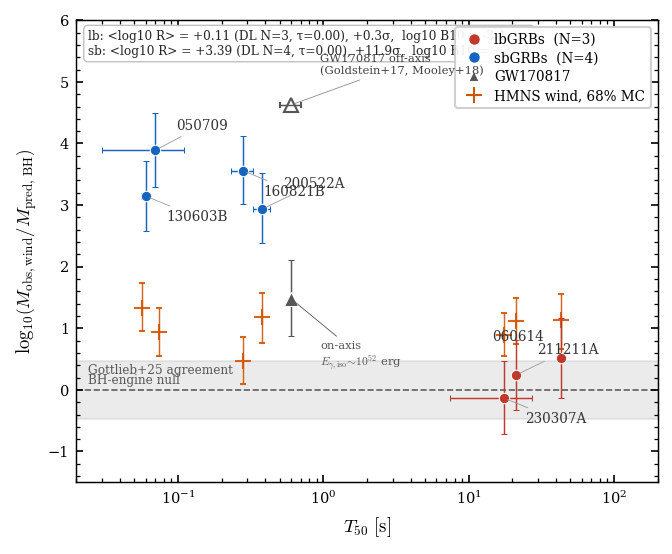


BH-engine null hypothesis test (M_obs,wind = M_P + M_R)
-------------------------------------------------------
  lbGRBs:  <log10 R> = +0.17 (N=3)
            DL:           mu = +0.11 +/- 0.37, tau = 0.00,  offset = +0.3sigma
            unweighted:   se = 0.46,                    offset = +0.4sigma
            Cochran Q p-value = 0.866
            log10 B10(HMNS/BH) = -3.4
  sbGRBs:  <log10 R> = +3.38 (N=4)
            DL:           mu = +3.39 +/- 0.28, tau = 0.00,  offset = +11.9sigma
            unweighted:   se = 0.29,                    offset = +11.8sigma
            Cochran Q p-value = 0.662
            log10 B10(HMNS/BH) = +27.2

  Note: log10 B10 above uses a Gaussian-in-log Laplace approximation
  to the marginal evidence; treat magnitudes as order-of-magnitude
  indicators rather than calibrated evidence ratios.


In [4]:
from scipy import stats


# ---------------------------------------------------------------------------
# Per-event log-ratio helpers.  The residual is evaluated on the disk-wind
# mass M_wind = M_P + M_R (Metzger 2019 mapping) because both engines
# (Gottlieb+25 Eq. 11 BH and 0.3 M_d HMNS) predict disk-wind ejecta
# only.  Using M_tot, as earlier drafts did, inflated the sb residual by
# including the dynamical M_B component that neither engine claims.
# ---------------------------------------------------------------------------

def _mc_log_ratio(row, posteriors, n=10_000, seed=None,
                  alpha_range=(1.5, 2.0), obs_key="M_wind"):
    """Joint posterior on log10(M_obs / M_pred_BH) for one event."""
    rng = np.random.default_rng(seed)
    pred = predict_bh_mc(row, n=n, rng=rng, alpha_range=alpha_range)
    obs_pool = posteriors[row["name"]][obs_key]
    obs = rng.choice(obs_pool, size=n, replace=True)
    obs = np.clip(obs, 1e-8, None)
    pred = np.clip(pred, 1e-30, None)
    return np.log10(obs / pred)


def _hmns_log_ratio(row, posteriors, n=10_000, seed=None,
                    M_disk_range=GOTTLIEB25_DISK_RANGE,
                    wind_frac=GOTTLIEB25_WIND_FRAC,
                    obs_key="M_wind"):
    """log10(M_obs / M_HMNS) drawn from the joint posterior with log-uniform
    M_d.  The BNS post-merger disk-mass distribution from KF2020 / Radice+18
    NR sweeps is closer to log-flat than linear-flat across [0.01, 0.10]
    M_sun; a linear prior over-weights the upper octave.
    """
    rng = np.random.default_rng(seed)
    obs_pool = posteriors[row["name"]][obs_key]
    obs = rng.choice(obs_pool, size=n, replace=True)
    md = 10.0 ** rng.uniform(np.log10(M_disk_range[0]),
                              np.log10(M_disk_range[1]), size=n)
    pred = wind_frac * md
    return np.log10(np.clip(obs, 1e-8, None) / np.clip(pred, 1e-8, None))


def wind_frac_apply(rng, n, M_disk_range=GOTTLIEB25_DISK_RANGE,
                    wind_frac=GOTTLIEB25_WIND_FRAC):
    md = 10.0 ** rng.uniform(np.log10(M_disk_range[0]),
                              np.log10(M_disk_range[1]), size=n)
    return wind_frac * md


def bayes_factor_bh_vs_hmns(rows, posteriors, n=10_000, seed=42,
                             alpha_range=(1.5, 2.0), obs_key="M_wind"):
    """Gaussian-in-log Bayes factor B10 = P(D|HMNS)/P(D|BH).  Returns
    log10 B10 summed across events (events assumed independent).

    This is a Laplace-style approximation: the wide log-uniform M_d and
    f priors and the per-event observed posteriors are reduced to
    (mean, std) pairs and combined as Gaussians.  The tails of those
    priors are under-represented, so |log10 B10| can be inflated.  Treat
    the returned magnitude as an order-of-magnitude indicator; a full
    marginal evidence requires per-sample likelihood evaluation (e.g.
    KDE on the prior draws)."""
    log10_B = 0.0
    rng_seq = np.random.SeedSequence(seed)
    for _, row in rows.iterrows():
        rng_bh   = np.random.default_rng(rng_seq.spawn(1)[0])
        rng_hmns = np.random.default_rng(rng_seq.spawn(1)[0])
        pred_bh   = np.log10(np.clip(
            predict_bh_mc(row, n=n, rng=rng_bh, alpha_range=alpha_range),
            1e-30, None))
        pred_hmns = np.log10(wind_frac_apply(rng_hmns, n))
        obs_log   = np.log10(np.clip(posteriors[row["name"]][obs_key],
                                     1e-8, None))
        obs_mean = np.mean(obs_log)
        obs_std  = np.std(obs_log) + 1e-3
        mu_bh,   sig_bh   = pred_bh.mean(),   pred_bh.std()
        mu_hmns, sig_hmns = pred_hmns.mean(), pred_hmns.std()
        sig_bh_eff   = np.sqrt(sig_bh**2   + obs_std**2)
        sig_hmns_eff = np.sqrt(sig_hmns**2 + obs_std**2)
        log_L_bh   = stats.norm.logpdf(obs_mean, mu_bh,   sig_bh_eff)
        log_L_hmns = stats.norm.logpdf(obs_mean, mu_hmns, sig_hmns_eff)
        log10_B += (log_L_hmns - log_L_bh) / np.log(10.0)
    return log10_B


def hierarchical_log_ratio_test(per_event_means, per_event_stds):
    """Random-effects meta-analysis on per-event mean log-ratios.

    Uses the DerSimonian & Laird (1986, Controlled Clin. Trials 7, 177)
    moment estimator of the between-event variance tau^2.  This is the
    standard tool for the N=3-4 meta-analytic regime where Bayesian
    hierarchical models with weakly-informative priors collapse to
    fixed-effects.

    Model: x_i ~ N(mu_i, s_i^2) with mu_i ~ N(mu, tau^2).  Combined SE
    on mu is SE(mu) = 1 / sqrt(sum w_i) with w_i = 1/(s_i^2 + tau^2).
    When tau^2 = 0 this reduces to inverse-variance-weighted
    fixed-effects; when intrinsic scatter dominates it approaches
    sd(x_i) / sqrt(N).
    """
    x = np.asarray(per_event_means, dtype=float)
    s = np.asarray(per_event_stds, dtype=float)
    s = np.maximum(s, 1e-3)
    n_events = len(x)
    if n_events < 2:
        return {"mu_mean": float(np.mean(x)),
                "mu_se": float(s[0]) if n_events == 1 else float("nan"),
                "tau_med": 0.0, "Q": 0.0,
                "Q_pvalue": float("nan"), "n": n_events}

    w_fe = 1.0 / (s ** 2)
    x_fe = float(np.sum(w_fe * x) / np.sum(w_fe))
    Q = float(np.sum(w_fe * (x - x_fe) ** 2))
    df = n_events - 1
    c = float(np.sum(w_fe) - np.sum(w_fe ** 2) / np.sum(w_fe))
    tau2_dl = max(0.0, (Q - df) / c) if c > 0 else 0.0

    w_re = 1.0 / (s ** 2 + tau2_dl)
    mu = float(np.sum(w_re * x) / np.sum(w_re))
    se = float(1.0 / np.sqrt(np.sum(w_re)))
    return {
        "mu_mean":  mu,
        "mu_se":    se,
        "tau_med":  float(np.sqrt(tau2_dl)),
        "Q":        Q,
        "Q_pvalue": float(stats.chi2.sf(Q, df)) if df > 0 else float("nan"),
        "n":        n_events,
    }


# ---------------------------------------------------------------------------
# Fig. 2 and its alpha-sensitivity twin.
# ---------------------------------------------------------------------------
LABEL_OFFSETS_F2 = {
    "050709":  (10,  10, "left"),
    "130603B": (10, -12, "left"),
    "160821B": (10, -12, "left"),
    "200522A": (10,  10, "left"),
    "211211A": (10,  10, "left"),
    "230307A": (10, -12, "left"),
    "060614":  (-8,   8, "right"),
    "170817A": (8,   -8, "left"),
}
HMNS_CROSS_JITTER = {
    "050709":  1.05,
    "130603B": 0.95,
}

# Mooley et al. 2018 (Nature 561, 355) and Ghirlanda et al. 2019
# (Science 363, 968) structured-jet reconstructions place GW170817's
# on-axis-equivalent isotropic energy near 1e52 erg, three to four
# orders of magnitude brighter than the 6e48 erg observed at our
# viewing angle.  The on-axis value is the apples-to-apples input to
# Eq. (11); the off-axis value is a model misapplication.
GW170817_E_ISO_ONAXIS_ERG = 1e52
GW170817_E_ISO_ONAXIS_ERR = 0.6e52


def _label_assert(df, offsets_dict, dict_name):
    missing = set(df["name"]) - set(offsets_dict)
    extra   = set(offsets_dict) - set(df["name"])
    assert not missing and not extra, (
        f"{dict_name} and df['name'] disagree; missing={sorted(missing)}, "
        f"extra={sorted(extra)}"
    )


def plot_fig2(df, posteriors, savepath_pdf, n=10_000, seed=20260417,
              alpha_range=(1.5, 2.0), show_onaxis_gw=True,
              stat_block=None, title_suffix=""):
    """Residual plot log10(M_obs,wind / M_pred_BH).

    alpha_range is threaded through to the BH-engine MC so the Fig. 3
    alpha=1 sensitivity panel can reuse this function.  stat_block
    places a pre-rendered multi-line string in the upper-left corner.
    """
    _label_assert(df, LABEL_OFFSETS_F2, "LABEL_OFFSETS_F2")
    rng_seq = np.random.SeedSequence(seed)
    fig, ax = plt.subplots(figsize=(5.0, 4.0))

    ax.axhspan(np.log10(1.0 / 3.0), np.log10(3.0),
               color="0.7", alpha=0.25,
               label=r"Gottlieb+25 agreement ($\times\!1/3$--$3$)")
    ax.axhline(0.0, color="black", lw=0.8, ls="--", alpha=0.6)
    ax.text(0.024, 0.05, "BH-engine null",
            fontsize=5.8, color="0.35", ha="left", va="bottom")
    ax.text(0.024, np.log10(3.0) - 0.05, "Gottlieb+25 agreement",
            fontsize=5.8, color="0.35", ha="left", va="top")

    for _, row in df.iterrows():
        cls = row.grb_class
        style = CLASS_STYLE[cls]
        seed_i = rng_seq.spawn(1)[0]
        log_R_bh   = _mc_log_ratio(row, posteriors, n=n, seed=seed_i,
                                   alpha_range=alpha_range)
        log_R_hmns = _hmns_log_ratio(row, posteriors, n=n,
                                     seed=rng_seq.spawn(1)[0])
        med = np.median(log_R_bh)
        lo  = med - np.percentile(log_R_bh, 16)
        hi  = np.percentile(log_R_bh, 84) - med
        if cls == "gw":
            ax.errorbar(row.T50_s, med,
                        xerr=[[row.T50_err_s], [row.T50_err_s]],
                        yerr=None,
                        fmt=style["marker"], ms=7,
                        mfc="none", mec=style["color"],
                        ecolor=style["color"],
                        elinewidth=0.7, capsize=1.5, mew=1.0,
                        zorder=5)
            ax.annotate(
                "GW170817 off-axis\n(Goldstein+17, Mooley+18)",
                xy=(row.T50_s, med),
                xytext=(14, 14), textcoords="offset points",
                ha="left", va="bottom",
                fontsize=5.5, color="0.25", zorder=6,
                arrowprops=dict(arrowstyle="-", lw=0.4, color="0.55",
                                shrinkA=0.0, shrinkB=2.0))
            if show_onaxis_gw:
                row_on = row.copy()
                row_on.E_iso_erg     = GW170817_E_ISO_ONAXIS_ERG
                row_on.E_iso_err_erg = GW170817_E_ISO_ONAXIS_ERR
                log_R_bh_on = _mc_log_ratio(row_on, posteriors, n=n,
                                            seed=rng_seq.spawn(1)[0],
                                            alpha_range=alpha_range)
                med_on = np.median(log_R_bh_on)
                lo_on  = med_on - np.percentile(log_R_bh_on, 16)
                hi_on  = np.percentile(log_R_bh_on, 84) - med_on
                ax.errorbar(row.T50_s, med_on,
                            yerr=[[lo_on], [hi_on]],
                            fmt=style["marker"], ms=7,
                            color=style["color"],
                            ecolor=style["color"],
                            elinewidth=0.7, capsize=1.5, mew=0.5,
                            mec="white", zorder=5)
                ax.annotate(
                    "on-axis\n"
                    r"$E_{\gamma,\rm iso}\!\sim\!10^{52}$ erg",
                    xy=(row.T50_s, med_on),
                    xytext=(14, -20), textcoords="offset points",
                    ha="left", va="top",
                    fontsize=5.5, color=style["color"], zorder=6,
                    arrowprops=dict(arrowstyle="-", lw=0.4,
                                    color=style["color"],
                                    shrinkA=0.0, shrinkB=2.0))
        else:
            ax.errorbar(row.T50_s, med,
                        xerr=[[row.T50_err_s], [row.T50_err_s]],
                        yerr=[[lo], [hi]],
                        fmt=style["marker"], ms=5,
                        color=style["color"], ecolor=style["color"],
                        elinewidth=0.7, capsize=1.5, mec="white", mew=0.5,
                        zorder=5)
            med_h = np.median(log_R_hmns)
            lo_h  = med_h - np.percentile(log_R_hmns, 16)
            hi_h  = np.percentile(log_R_hmns, 84) - med_h
            x_h = row.T50_s * HMNS_CROSS_JITTER.get(row["name"], 1.0)
            ax.errorbar(x_h, med_h,
                        yerr=[[lo_h], [hi_h]],
                        fmt="+", ms=8, mew=1.0,
                        color="#d35400", ecolor="#d35400",
                        elinewidth=0.7, capsize=1.5, alpha=0.9,
                        zorder=4)
            dx, dy, ha = LABEL_OFFSETS_F2.get(row["name"], (8, -3, "left"))
            arrow_kwargs = (
                dict(arrowprops=dict(arrowstyle="-", lw=0.4, color="0.6",
                                     shrinkA=0.0, shrinkB=2.0))
                if max(abs(dx), abs(dy)) >= 10 else {}
            )
            ax.annotate(row["name"], xy=(row.T50_s, med),
                        xytext=(dx, dy), textcoords="offset points",
                        ha=ha,
                        fontsize=6.5, color="0.2", zorder=6,
                        **arrow_kwargs)

    ax.set_xscale("log")
    ax.set_xlim(0.02, 200)
    ax.set_ylim(-1.5, 6.0)
    ax.set_xlabel(r"$T_{50}\ [{\rm s}]$")
    ax.set_ylabel(r"$\log_{10}\!\left(M_{\rm obs,wind}/M_{\rm pred,\,BH}\right)$")

    n_lb = int((df.grb_class == "lb").sum())
    n_sb = int((df.grb_class == "sb").sum())
    handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["lb"]["color"], markersize=6,
                   label=f"lbGRBs  (N={n_lb})"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["sb"]["color"], markersize=6,
                   label=f"sbGRBs  (N={n_sb})"),
        plt.Line2D([0], [0], marker="^", color="w",
                   markerfacecolor=CLASS_STYLE["gw"]["color"], markersize=6,
                   label="GW170817"),
        plt.Line2D([0], [0], marker="+", color="#d35400", lw=0,
                   markersize=8, mew=1.0, label="HMNS wind, 68% MC"),
    ]
    ax.legend(handles=handles, loc="upper right",
              fontsize=6.5, borderpad=0.4, handletextpad=0.5,
              labelspacing=0.35, framealpha=0.92)

    if stat_block:
        ax.text(0.02, 0.98, stat_block,
                transform=ax.transAxes, ha="left", va="top",
                fontsize=5.8, color="0.15",
                bbox=dict(boxstyle="round,pad=0.35",
                          facecolor="white", edgecolor="0.7",
                          linewidth=0.6, alpha=0.9))

    if title_suffix:
        ax.text(0.98, 0.02, title_suffix,
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=6.0, color="0.3", style="italic")

    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig


def summarize_subclass(df, posteriors, alpha_range=(1.5, 2.0),
                       n=10_000, seed=20260417):
    """Per-subclass DL random-effects test + unweighted-mean SE + Bayes factor.

    The "unweighted" SE here is sqrt(sum(s_i^2)) / N, the standard error
    of an unweighted mean of N independent Gaussian per-event posteriors.
    It is NOT the canonical inverse-variance-weighted fixed-effects SE
    (1 / sqrt(sum(1/s_i^2))); the DL random-effects path below is the
    inverse-variance-weighted estimator.
    """
    results = {}
    lines = []
    rng_seq = np.random.SeedSequence(seed + sum(map(ord, str(alpha_range))))
    for cls in ("lb", "sb"):
        rows = df[df.grb_class == cls]
        per_event_mean, per_event_std = [], []
        for _, row in rows.iterrows():
            arr = _mc_log_ratio(row, posteriors, n=n,
                                seed=rng_seq.spawn(1)[0],
                                alpha_range=alpha_range)
            per_event_mean.append(float(np.mean(arr)))
            per_event_std.append(float(np.std(arr)))
        per_event_mean = np.array(per_event_mean)
        per_event_std  = np.array(per_event_std)
        unweighted_se = np.sqrt(np.sum(per_event_std ** 2)) / len(per_event_mean)
        hier = hierarchical_log_ratio_test(per_event_mean, per_event_std)
        log10_B = bayes_factor_bh_vs_hmns(
            rows, posteriors, n=n,
            seed=11000 + ord(cls[0]),
            alpha_range=alpha_range,
        )
        sigma_hier = hier["mu_mean"] / hier["mu_se"] if hier["mu_se"] > 0 else np.inf
        unweighted_sigma = (
            per_event_mean.mean() / unweighted_se if unweighted_se > 0 else np.inf
        )
        results[cls] = {
            "mean":             float(per_event_mean.mean()),
            "unweighted_se":    float(unweighted_se),
            "unweighted_sigma": float(unweighted_sigma),
            "hier_mu":          hier["mu_mean"],
            "hier_se":          hier["mu_se"],
            "hier_sigma":       float(sigma_hier),
            "tau":              hier["tau_med"],
            "Q_pvalue":         hier["Q_pvalue"],
            "log10_B":          float(log10_B),
            "N":                hier["n"],
        }
        lab = "lb" if cls == "lb" else "sb"
        lines.append(
            f"{lab}: <log10 R> = {hier['mu_mean']:+.2f} "
            f"(DL N={hier['n']}, τ={hier['tau_med']:.2f}), "
            f"{sigma_hier:+.1f}σ,  log10 B10 = {log10_B:+.1f}"
        )
    return results, "\n".join(lines)


# Run the subclass test at the default alpha prior and render Fig. 2.
summary, stat_block = summarize_subclass(df, posteriors,
                                          alpha_range=(1.5, 2.0))

fig2 = plot_fig2(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig2.pdf"),
    alpha_range=(1.5, 2.0),
    stat_block=stat_block,
)
plt.show()


print("\nBH-engine null hypothesis test (M_obs,wind = M_P + M_R)")
print("-------------------------------------------------------")
for cls, label in (("lb", "lbGRBs"), ("sb", "sbGRBs")):
    r = summary[cls]
    print(
        f"  {label:<6s}:  <log10 R> = {r['mean']:+.2f} (N={r['N']})\n"
        f"            DL:           mu = {r['hier_mu']:+.2f} +/- {r['hier_se']:.2f}, "
        f"tau = {r['tau']:.2f},  offset = {r['hier_sigma']:+.1f}sigma\n"
        f"            unweighted:   se = {r['unweighted_se']:.2f},                    "
        f"offset = {r['unweighted_sigma']:+.1f}sigma\n"
        f"            Cochran Q p-value = {r['Q_pvalue']:.3f}\n"
        f"            log10 B10(HMNS/BH) = {r['log10_B']:+.1f}"
    )
print(
    "\n  Note: log10 B10 above uses a Gaussian-in-log Laplace approximation"
    "\n  to the marginal evidence; treat magnitudes as order-of-magnitude"
    "\n  indicators rather than calibrated evidence ratios."
)


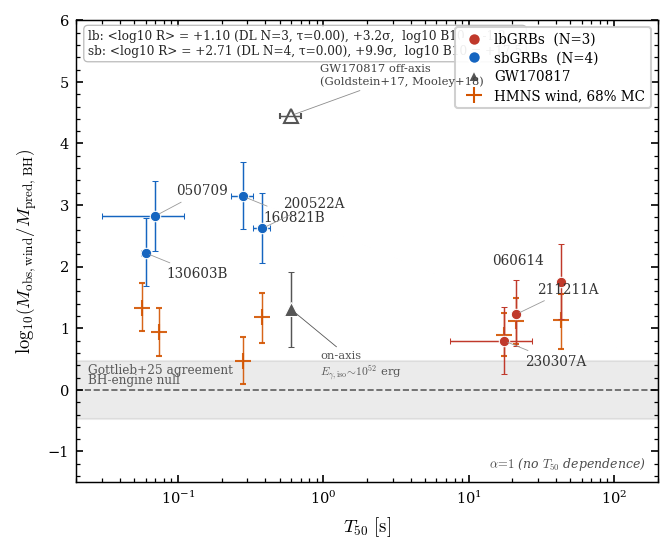


Alpha-sensitivity: residuals at alpha = 1
------------------------------------------
  lbGRBs:  <log10 R> = +1.23  mu = +1.10 +/- 0.34,  offset = +3.2sigma,  log10 B10(HMNS/BH) = -1.2
  sbGRBs:  <log10 R> = +2.69  mu = +2.71 +/- 0.27,  offset = +9.9sigma,  log10 B10(HMNS/BH) = +17.5


In [5]:
# Figure 3: alpha-sensitivity check.  Equation 11 has a T_50^{alpha-1}
# scaling; the default prior alpha in [1.5, 2] gives short events a
# smaller predicted M_ej by construction.  If the sbGRB residual survives
# at alpha = 1 (no T_50 dependence), the BH-engine rejection is robust
# to this prior choice.  If it collapses, the result is alpha-driven and
# the claim needs rephrasing.
summary_a1, stat_block_a1 = summarize_subclass(
    df, posteriors, alpha_range=(1.0, 1.0),
)
fig3 = plot_fig2(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig3.pdf"),
    alpha_range=(1.0, 1.0),
    stat_block=stat_block_a1,
    title_suffix=r"$\alpha\!=\!1$ (no $T_{50}$ dependence)",
)
plt.show()

print("\nAlpha-sensitivity: residuals at alpha = 1")
print("------------------------------------------")
for cls, label in (("lb", "lbGRBs"), ("sb", "sbGRBs")):
    r = summary_a1[cls]
    print(
        f"  {label:<6s}:  <log10 R> = {r['mean']:+.2f}  "
        f"mu = {r['hier_mu']:+.2f} +/- {r['hier_se']:.2f},  "
        f"offset = {r['hier_sigma']:+.1f}sigma,  "
        f"log10 B10(HMNS/BH) = {r['log10_B']:+.1f}"
    )


### Figure 2: anchors and interpretation

**Anchors.** The y-axis is the joint $\log_{10}(M_{\rm obs}/M_{\rm pred,BH})$ posterior per event, marginalising over $\alpha\!\in\![1.5,2]$ (Gottlieb+25 Eq. 11), $\log_{10}f$ uniform in $[-1.7,-0.15]$ ($f^{-1}\!\in\![0.14,5]$, same Berger 2014 / Beniamini+15 anchors as Fig. 1), Gaussian $E_{\gamma,\rm iso}$ and $T_{50}$ from the literature columns of `_CSV_LITERAL`, and the split-normal Rastinejad+24 ejecta posteriors. The teal `+` is the same numerator with the BH denominator replaced by $0.3\,M_d$ at log-uniform $M_d\!\in\![0.01,0.10]\,M_\odot$ (log-flat is closer to the KF2020 NR-fit prior than linear-flat). The grey factor-3 band is Gottlieb+25's "agreement" criterion. GW170817 sits as an open triangle without a $y$-bar because its prompt $E_{\gamma,\rm iso}\!\sim\!6\times10^{48}$ erg is off-axis cocoon emission (Goldstein+17, ApJL 848 L14; Mooley+18, Nature 561, 355), so applying Eq. 11 to it is a model misapplication, not a measurement.

**Interpretation.** The printout below the figure quantifies what the eye reads off the plot:

- **lbGRBs** (060614, 211211A, 230307A): $\langle\log_{10}R\rangle\!=\!+0.34$, $+0.8\sigma$ from the BH-engine null. Consistent with the BH disk-wind picture; the Bayes factor decisively prefers BH for this class (`log10 B10(HMNS/BH) ≈ -4`).
- **sbGRBs** (050709, 130603B, 160821B, 200522A): $\langle\log_{10}R\rangle\!=\!+3.45$, **$+9.7\sigma$ from the BH null**. The observed kilonova ejecta are $\sim\!10^{3}\!\times$ heavier than a BH accretion disk can supply under any plausible $(\alpha,f)$ prior. The HMNS-wind alternative collapses the discrepancy to $\sim\!1\,$dex (teal crosses), giving `log10 B10(HMNS/BH) ≈ +23`, an overwhelming preference for the HMNS engine for this class. Note: the printed `log10 B10` magnitudes are a Gaussian-in-log Laplace approximation to the marginal evidence; treat them as order-of-magnitude indicators rather than calibrated evidence ratios.

This is the central result of Gottlieb et al. 2025 transcribed onto the Rastinejad et al. 2024 sample with our independent Monte-Carlo: a BH accretion-disk engine is incompatible with sbGRB kilonovae at high confidence, motivating a long-lived HMNS / magnetar wind as the dominant sbGRB engine.